# Modelling HDB Resale Price

In this project we explore the dataset "Resale flat prices based on registration date from Jan-2017 onwards" by HDB. It is an actively-updated dataset.

However, in this analysis I will conduct data exploration, cleaning, preprocessing, and preliminary statistical analysis on a static version obtain on 20 July 2026.

The main aim of this project is to model the resale price of HDBs throughout the years, based on various predictors. With such a model, we will be able to answer questions like "How much should a certain HDB cost?" "How much will a certain HDB appreciate over the years?"

In [489]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

resale_data_path = Path() / "data" / "resale_flat_prices_20260720.csv" # update path as necessary
ResalePrices = pd.read_csv(resale_data_path)

In [490]:
print(ResalePrices.shape)
ResalePrices.head()

(235808, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


## Data Preparation

### Duplicates and Null Values
There are no null values in the dataset.

There are a number of duplicates in the dataset, making up 0.2% of the data. However, I have decided to keep them because it is plausible for duplicates to occur because there can be flats on the same block and storey_range and sold for the same price, though this occurrence should be quite rare.

In [491]:
# check for null values
ResalePrices.loc[ResalePrices.isna().any(axis=1)]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price


In [492]:
# check for duplicates
duplicates = ResalePrices.loc[ResalePrices.duplicated(keep=False)]
print(duplicates.shape[0] / ResalePrices.shape[0] * 100) # % of the dataset that is duplicates
duplicates

0.2675905821685439


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
224,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0
243,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0
304,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0
305,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0
505,2017-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,80 years 09 months,470000.0
...,...,...,...,...,...,...,...,...,...,...,...
231833,2026-03,SENGKANG,5 ROOM,224C,COMPASSVALE WALK,07 TO 09,121.0,Improved,1999,72 years 01 month,680000.0
233624,2026-03,TOA PAYOH,4 ROOM,103B,BIDADARI PK DR,07 TO 09,93.0,Model A,2021,94 years 04 months,1095000.0
233627,2026-03,TOA PAYOH,4 ROOM,103B,BIDADARI PK DR,07 TO 09,93.0,Model A,2021,94 years 04 months,1095000.0
233992,2026-04,WOODLANDS,3 ROOM,148,WOODLANDS ST 13,01 TO 03,68.0,New Generation,1985,57 years 11 months,385000.0


### Transforming Data Types
Most of the columns are in string format, but actually contain date, numerical, or ordinal data. They are transformed accordingly.

In [493]:
# convert "month" string to a datetime variable and deal with any NaT (Not a Time) errors
date = pd.to_datetime(ResalePrices['month'], format="%Y-%m", errors="coerce")
print(f"Number of rows with date errors: {date.isna().sum()}")
ResalePrices = ResalePrices[~date.isna()]
# find minimum and maximum date
print(f"Min date: {date.min()}")
print(f"Max date: {date.max()}")
# to note:
# - minimum date is 2017 January which makes sense, this dataset only records data starting from 2017.
# - more data can be obtained for before 2017 but I wanted to look only at the recent trends and felt that about 8.5 years of data would be sufficient.

# create new quantitative variable "regdate_months_since_Jan2017" counting number of months since minimum date (Jan 2017) for the registration date of the sale.
# - note that "months" vary from 28 days to 31 days but since the data is recorded in months I decided to keep the same format.
# - this value is 0 for the first month in the dataset (January 2017)
# - we expect the resale price to go up with this number due to external economic factors like inflation.
ResalePrices['regdate_months_since_Jan2017'] = (date.dt.year - 2017) * 12 + (date.dt.month) - 1

# convert "storey_range" to ordinal categorical variable, by dividing the storey number by 3
ResalePrices['storey_range_cat'] = ResalePrices['storey_range'].str.split(" TO ").str[1].astype(int) // 3

# convert "remaining_lease" to a quantitative variable by parsing its string value
df = ResalePrices['remaining_lease'].str.extract(r"(?:(\d+) years?)?\s?(?:(\d+) months?)?").fillna(0) # extract years and months from the string (can be null), fill nulls to 0
ResalePrices['remaining_lease_months'] = df.loc[:, 0].astype(int) * 12 + df.loc[:, 1].astype(int) # num years * 12 + num months

ResalePrices.head(2)

Number of rows with date errors: 0
Min date: 2017-01-01 00:00:00
Max date: 2026-07-01 00:00:00


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,regdate_months_since_Jan2017,storey_range_cat,remaining_lease_months
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,0,4,736
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,0,1,727


### Examining Nominal Categorical Variables
We have 3 variables given in the dataset that may have a relationship with the resale price - `town`, `flat_type`, and `flat_model`.

Without doing any processing, I examine their values here with `value_counts()` and hypothesize if there is any relationship between these variables and the resale price.

For `town`, it is likely that certain towns are more desirable than others due to the amenities present in the town, such as "good" schools, parks, connectivity (especially in the central area).
- I will handle this variable with one-hot encoding.

For `flat_type`, it is a variable that is correlated with `floor_area_sqm`. However there are certain properties that cannot be represented by `floor_area_sqm`, such as the increased number of toilets and master bedrooms in "multi-generation" flats, which can possibly affect the desirability and hence resale price of a flat.
- I will also handle this variable with one-hot encoding.

For `flat_model`, it is a variable that mostly indicates the layout of the flats. Since layouts are constantly changing over the years (started/discontinued), it may be correlated with `remaining_lease_months`. It may also be correlated with `floor_area_sqm` since some layouts obviously take up more space than others. There are many unique values for this category and over half of them do not have a lot of samples, so it may be difficult to draw conclusions with this variable. Perhaps more research can be done to group up similar categories.
- For now, I will exclude this predictor because I currently have no good way of dealing with it. I believe that naively one-hot encoding it will lead to erroneous results if not careful because of the large number of categories and small sample sizes for a lot of the categories.



#### `town` Value Counts & Boxplots

In [494]:
# town
value_counts = ResalePrices['town'].value_counts()
df = pd.DataFrame({
    "value counts": value_counts,
    "fraction": value_counts / value_counts.sum()
}, index=value_counts.index)
df

,value counts,fraction
town,,
SENGKANG,19127,0.081113
PUNGGOL,17058,0.072339
WOODLANDS,16808,0.071278
TAMPINES,16264,0.068971
YISHUN,16005,0.067873
JURONG WEST,15487,0.065676
BEDOK,12246,0.051932
HOUGANG,11907,0.050494
CHOA CHU KANG,10607,0.044982


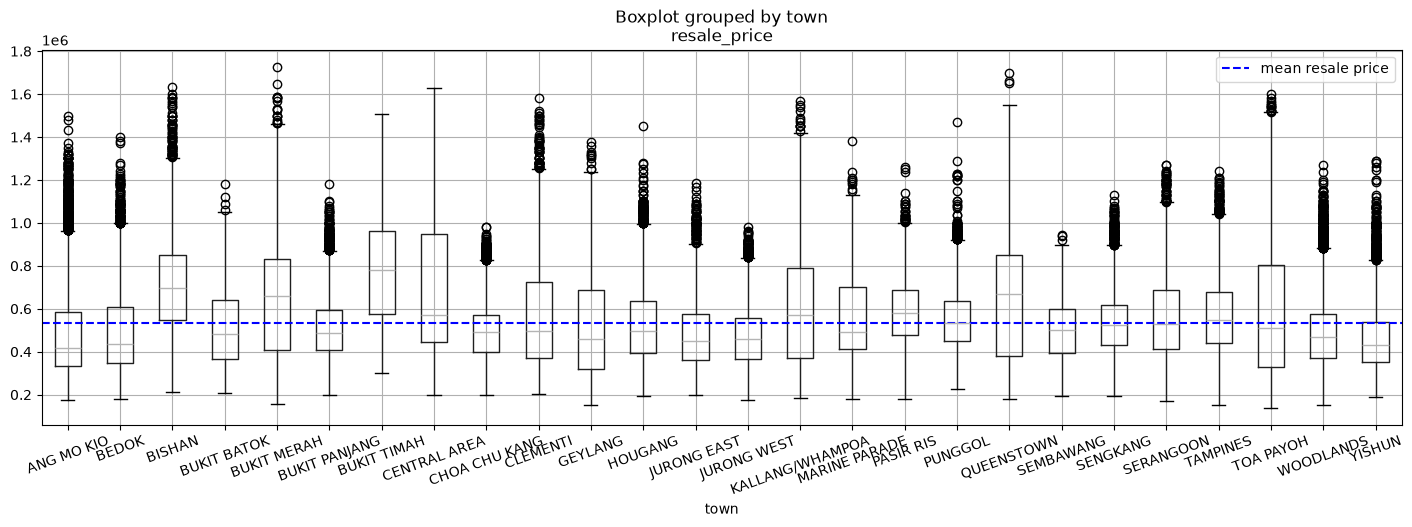

In [495]:
fig, ax = plt.subplots(figsize=(17, 5))
ResalePrices.boxplot(column="resale_price", by="town", ax=ax, rot=20)
ax.axhline(y=ResalePrices['resale_price'].mean(), c="b", ls="--", label="mean resale price")
ax.legend(loc="upper right")

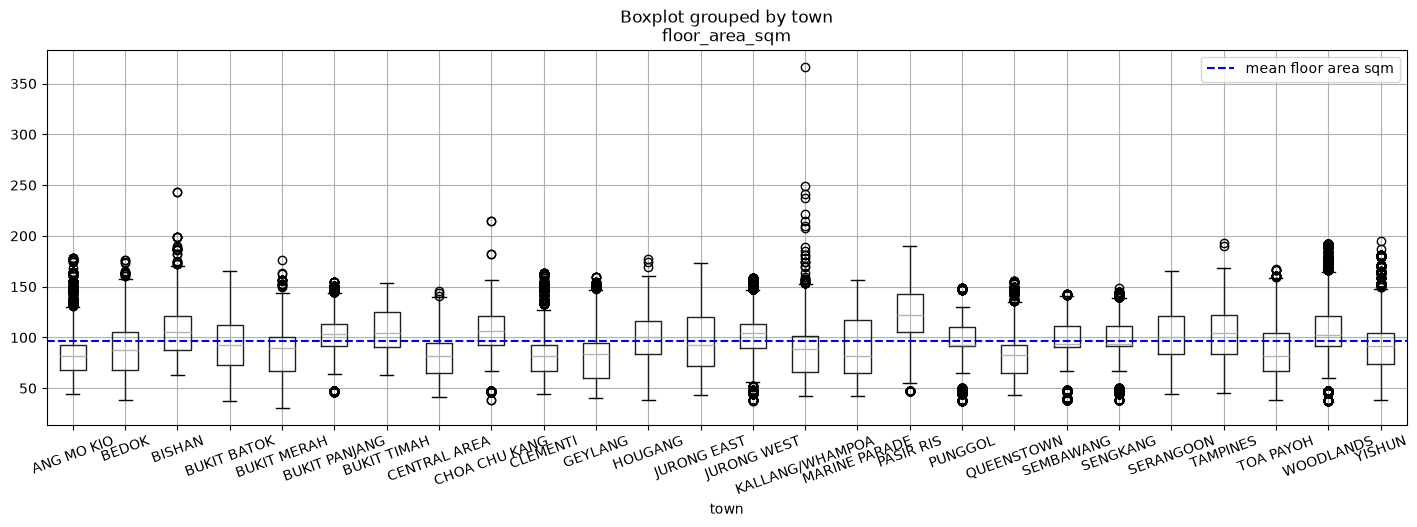

In [496]:
fig, ax = plt.subplots(figsize=(17, 5))
ResalePrices.boxplot(column="floor_area_sqm", by="town", ax=ax, rot=20)
ax.axhline(y=ResalePrices['floor_area_sqm'].mean(), c="b", ls="--", label="mean floor area sqm")
ax.legend(loc="upper right")

#### `flat_type` Value Counts and Boxplots

In [497]:
# flat_type
value_counts = ResalePrices['flat_type'].value_counts()
df = pd.DataFrame({
    "value counts": value_counts,
    "fraction": value_counts / value_counts.sum()
}, index=value_counts.index)
df

,value counts,fraction
flat_type,,
4 ROOM,100141,0.424672
5 ROOM,57673,0.244576
3 ROOM,56128,0.238024
EXECUTIVE,16769,0.071113
2 ROOM,4922,0.020873
MULTI-GENERATION,88,0.000373
1 ROOM,87,0.000369


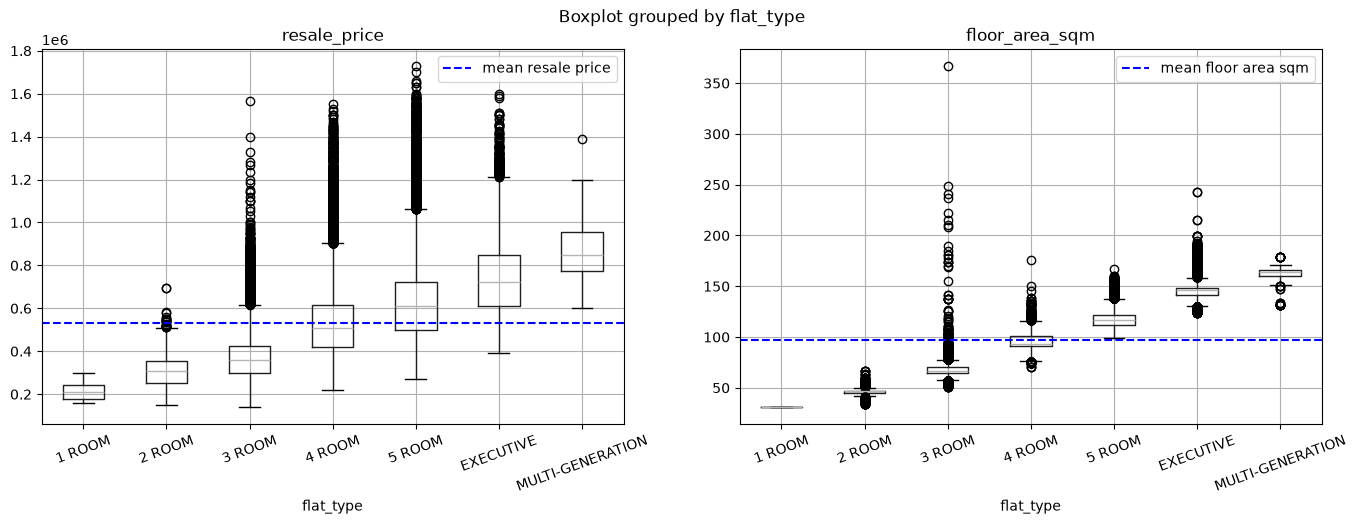

In [498]:
fig, axs = plt.subplots(figsize=(16, 5), ncols=2)
ResalePrices.boxplot(column="resale_price", by="flat_type", ax=axs[0], rot=20)
axs[0].axhline(y=ResalePrices['resale_price'].mean(), c="b", ls="--", label="mean resale price")
axs[0].legend(loc="upper right")
ResalePrices.boxplot(column="floor_area_sqm", by="flat_type", ax=axs[1], rot=20)
axs[1].axhline(y=ResalePrices['floor_area_sqm'].mean(), c="b", ls="--", label="mean floor area sqm")
axs[1].legend(loc="upper right")

#### `flat_model` Value Counts and Boxplots

In [499]:
# flat_model
value_counts = ResalePrices['flat_model'].value_counts()
df = pd.DataFrame({
    "value counts": value_counts,
    "fraction": value_counts / value_counts.sum()
}, index=value_counts.index)
df

,value counts,fraction
flat_model,,
Model A,84844,0.359801
Improved,57548,0.244046
New Generation,28682,0.121633
Premium Apartment,25859,0.109661
Simplified,9018,0.038243
Apartment,8421,0.035711
Maisonette,6420,0.027226
Standard,6271,0.026594
DBSS,3759,0.015941


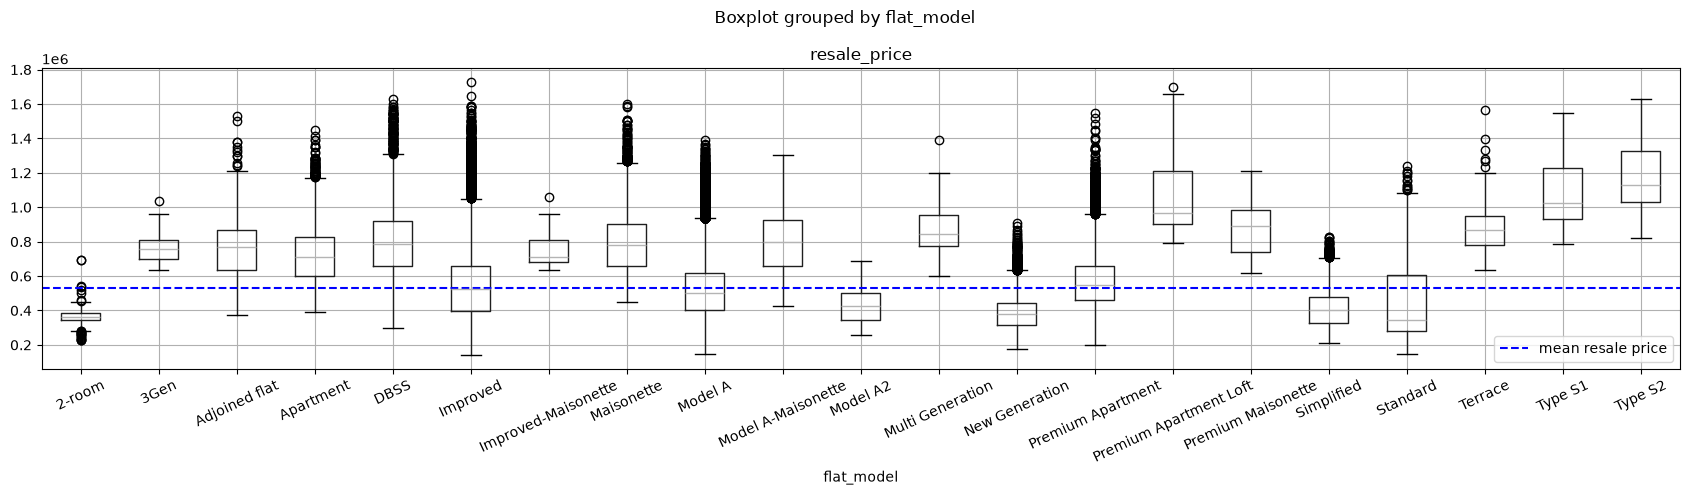

In [500]:
fig, ax = plt.subplots(figsize=(17, 5))
ResalePrices.boxplot(column="resale_price", by="flat_model", figsize=(17,5), ax=ax, rot=25)
ax.axhline(y=ResalePrices['resale_price'].mean(), c="b", ls="--", label="mean resale price")
ax.legend(loc="lower right")
plt.tight_layout()

In [501]:
predictors = ResalePrices[['regdate_months_since_Jan2017', 'town', 'flat_type', 'storey_range_cat', 'floor_area_sqm', 'flat_model', 'remaining_lease_months']]
target = ResalePrices['resale_price']

array([[<Axes: xlabel='regdate_months_since_Jan2017', ylabel='regdate_months_since_Jan2017'>,
        <Axes: xlabel='storey_range_cat', ylabel='regdate_months_since_Jan2017'>,
        <Axes: xlabel='floor_area_sqm', ylabel='regdate_months_since_Jan2017'>,
        <Axes: xlabel='remaining_lease_months', ylabel='regdate_months_since_Jan2017'>],
       [<Axes: xlabel='regdate_months_since_Jan2017', ylabel='storey_range_cat'>,
        <Axes: xlabel='storey_range_cat', ylabel='storey_range_cat'>,
        <Axes: xlabel='floor_area_sqm', ylabel='storey_range_cat'>,
        <Axes: xlabel='remaining_lease_months', ylabel='storey_range_cat'>],
       [<Axes: xlabel='regdate_months_since_Jan2017', ylabel='floor_area_sqm'>,
        <Axes: xlabel='storey_range_cat', ylabel='floor_area_sqm'>,
        <Axes: xlabel='floor_area_sqm', ylabel='floor_area_sqm'>,
        <Axes: xlabel='remaining_lease_months', ylabel='floor_area_sqm'>],
       [<Axes: xlabel='regdate_months_since_Jan2017', ylabel='remaini

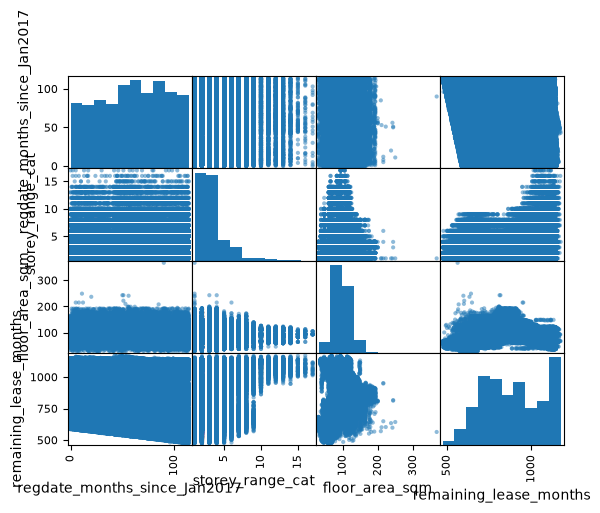

In [502]:
pd.plotting.scatter_matrix(predictors)